# BESTEST annual-load comparison: LBNL-5R1C, 5R1C, and 7R2C

This notebook uses cached CSV files only; it does **not** run Modelica, RClib, or VDI simulations.

- **LBNL-5R1C**: published LBNL `Modelica ISO13790` reference column.
- **5R1C**: `RClib-ISO + Modelica-resolved solar` from the cached ISO metrics.
- **7R2C**: `F36-like` from the cached VDI annual-results table.


In [1]:
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path

cwd = Path.cwd().resolve()
roots = (cwd, *cwd.parents)
ROOT = next((path for path in roots if (path / '3_combined/build_annual_load_comparison.py').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Could not locate 3_combined/build_annual_load_comparison.py')

script_path = ROOT / '3_combined/build_annual_load_comparison.py'
spec = spec_from_file_location('combined_bestest', script_path)
combined = module_from_spec(spec)
spec.loader.exec_module(combined)

output_dir = ROOT / '3_combined/outputs'
comparison = combined.build_comparison()
combined.render(comparison, output_dir)
comparison


,case,metric,lower_MWh,upper_MWh,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,LBNL-5R1C,5R1C,7R2C,bounds_valid,LBNL-5R1C_in_range,5R1C_in_range,7R2C_in_range
0,600,heating,3.75,4.98,4.050,3.993,4.047,4.324,4.362,4.504,4.658,4.582236,4.823417,True,True,True,True
1,610,heating,3.61,5.27,4.163,4.066,4.144,4.375,4.527,4.592,4.784,4.714909,4.955557,True,True,True,True
2,620,heating,3.67,5.38,4.370,4.094,4.297,4.485,4.514,4.719,4.824,4.768045,5.007976,True,True,True,True
3,630,heating,3.69,6.12,4.923,4.356,4.677,4.784,5.051,5.139,5.097,5.052480,5.254494,True,True,True,True
4,640,heating,1.58,3.76,2.682,2.403,2.619,2.662,2.654,2.653,2.898,2.566110,2.778307,True,True,True,True
5,650,heating,0.00,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000000,0.000000,True,True,True,True
6,660,heating,2.68,4.82,3.574,3.602,3.821,3.707,3.787,3.790,3.898,3.844761,3.726306,True,True,True,True
7,670,heating,4.00,7.96,5.484,5.300,5.573,5.616,5.975,6.140,7.381,7.302776,6.255516,True,True,True,True
8,680,heating,1.21,3.08,2.219,1.786,1.732,2.180,2.132,2.286,2.646,2.577225,2.611359,True,True,True,True
9,685,heating,4.08,5.75,4.532,4.574,4.646,4.877,4.904,5.042,5.063,4.982195,5.098300,True,True,True,True


In [2]:
valid = comparison.loc[comparison.bounds_valid]
summary = {
    outcome: int((valid[f'{outcome}_in_range'] == False).sum())
    for outcome in combined.OUTCOMES
}
print('Out-of-range outcomes (valid benchmark bounds only):', summary)
print('Rows with reversed/malformed benchmark limits:', int((~comparison.bounds_valid).sum()))
comparison.to_csv(output_dir / 'annual_load_comparison.csv', index=False)


Out-of-range outcomes (valid benchmark bounds only): {'LBNL-5R1C': 3, '5R1C': 3, '7R2C': 1}
Rows with reversed/malformed benchmark limits: 1


## Generated figures

Orange cells and bars are outside valid published bounds. Case 910 cooling retains its published reversed limits and therefore receives no range judgement.


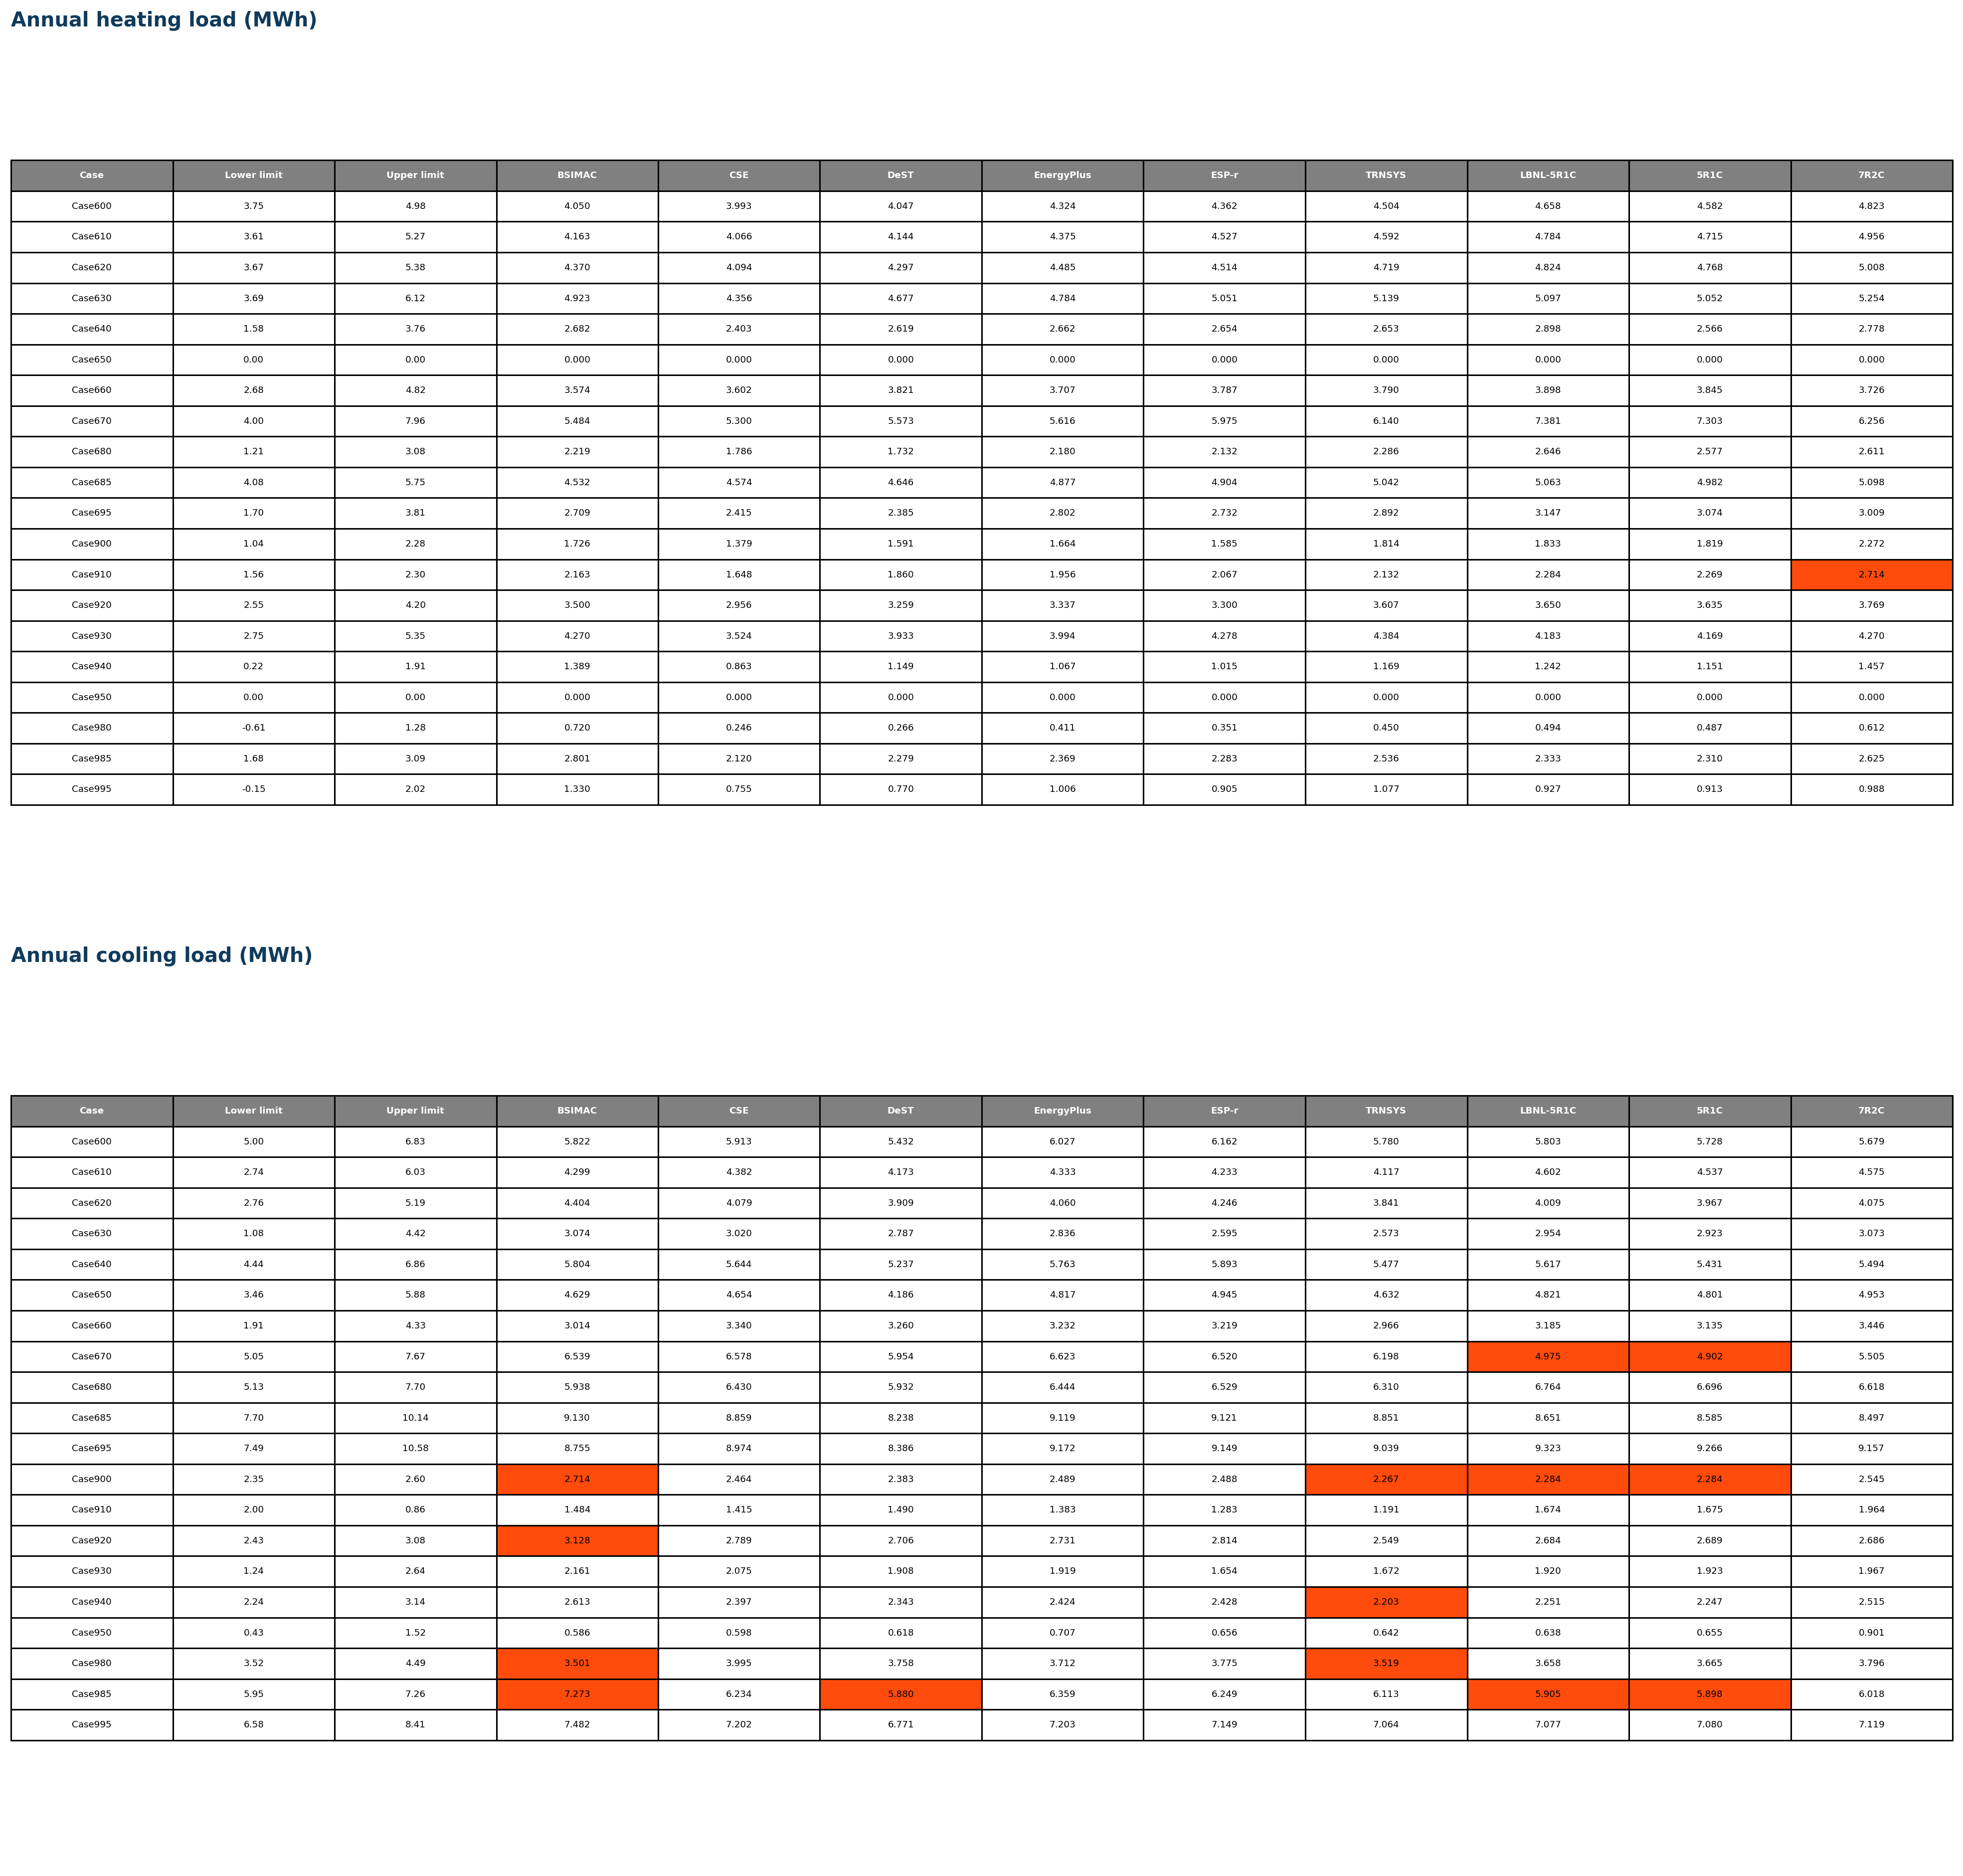

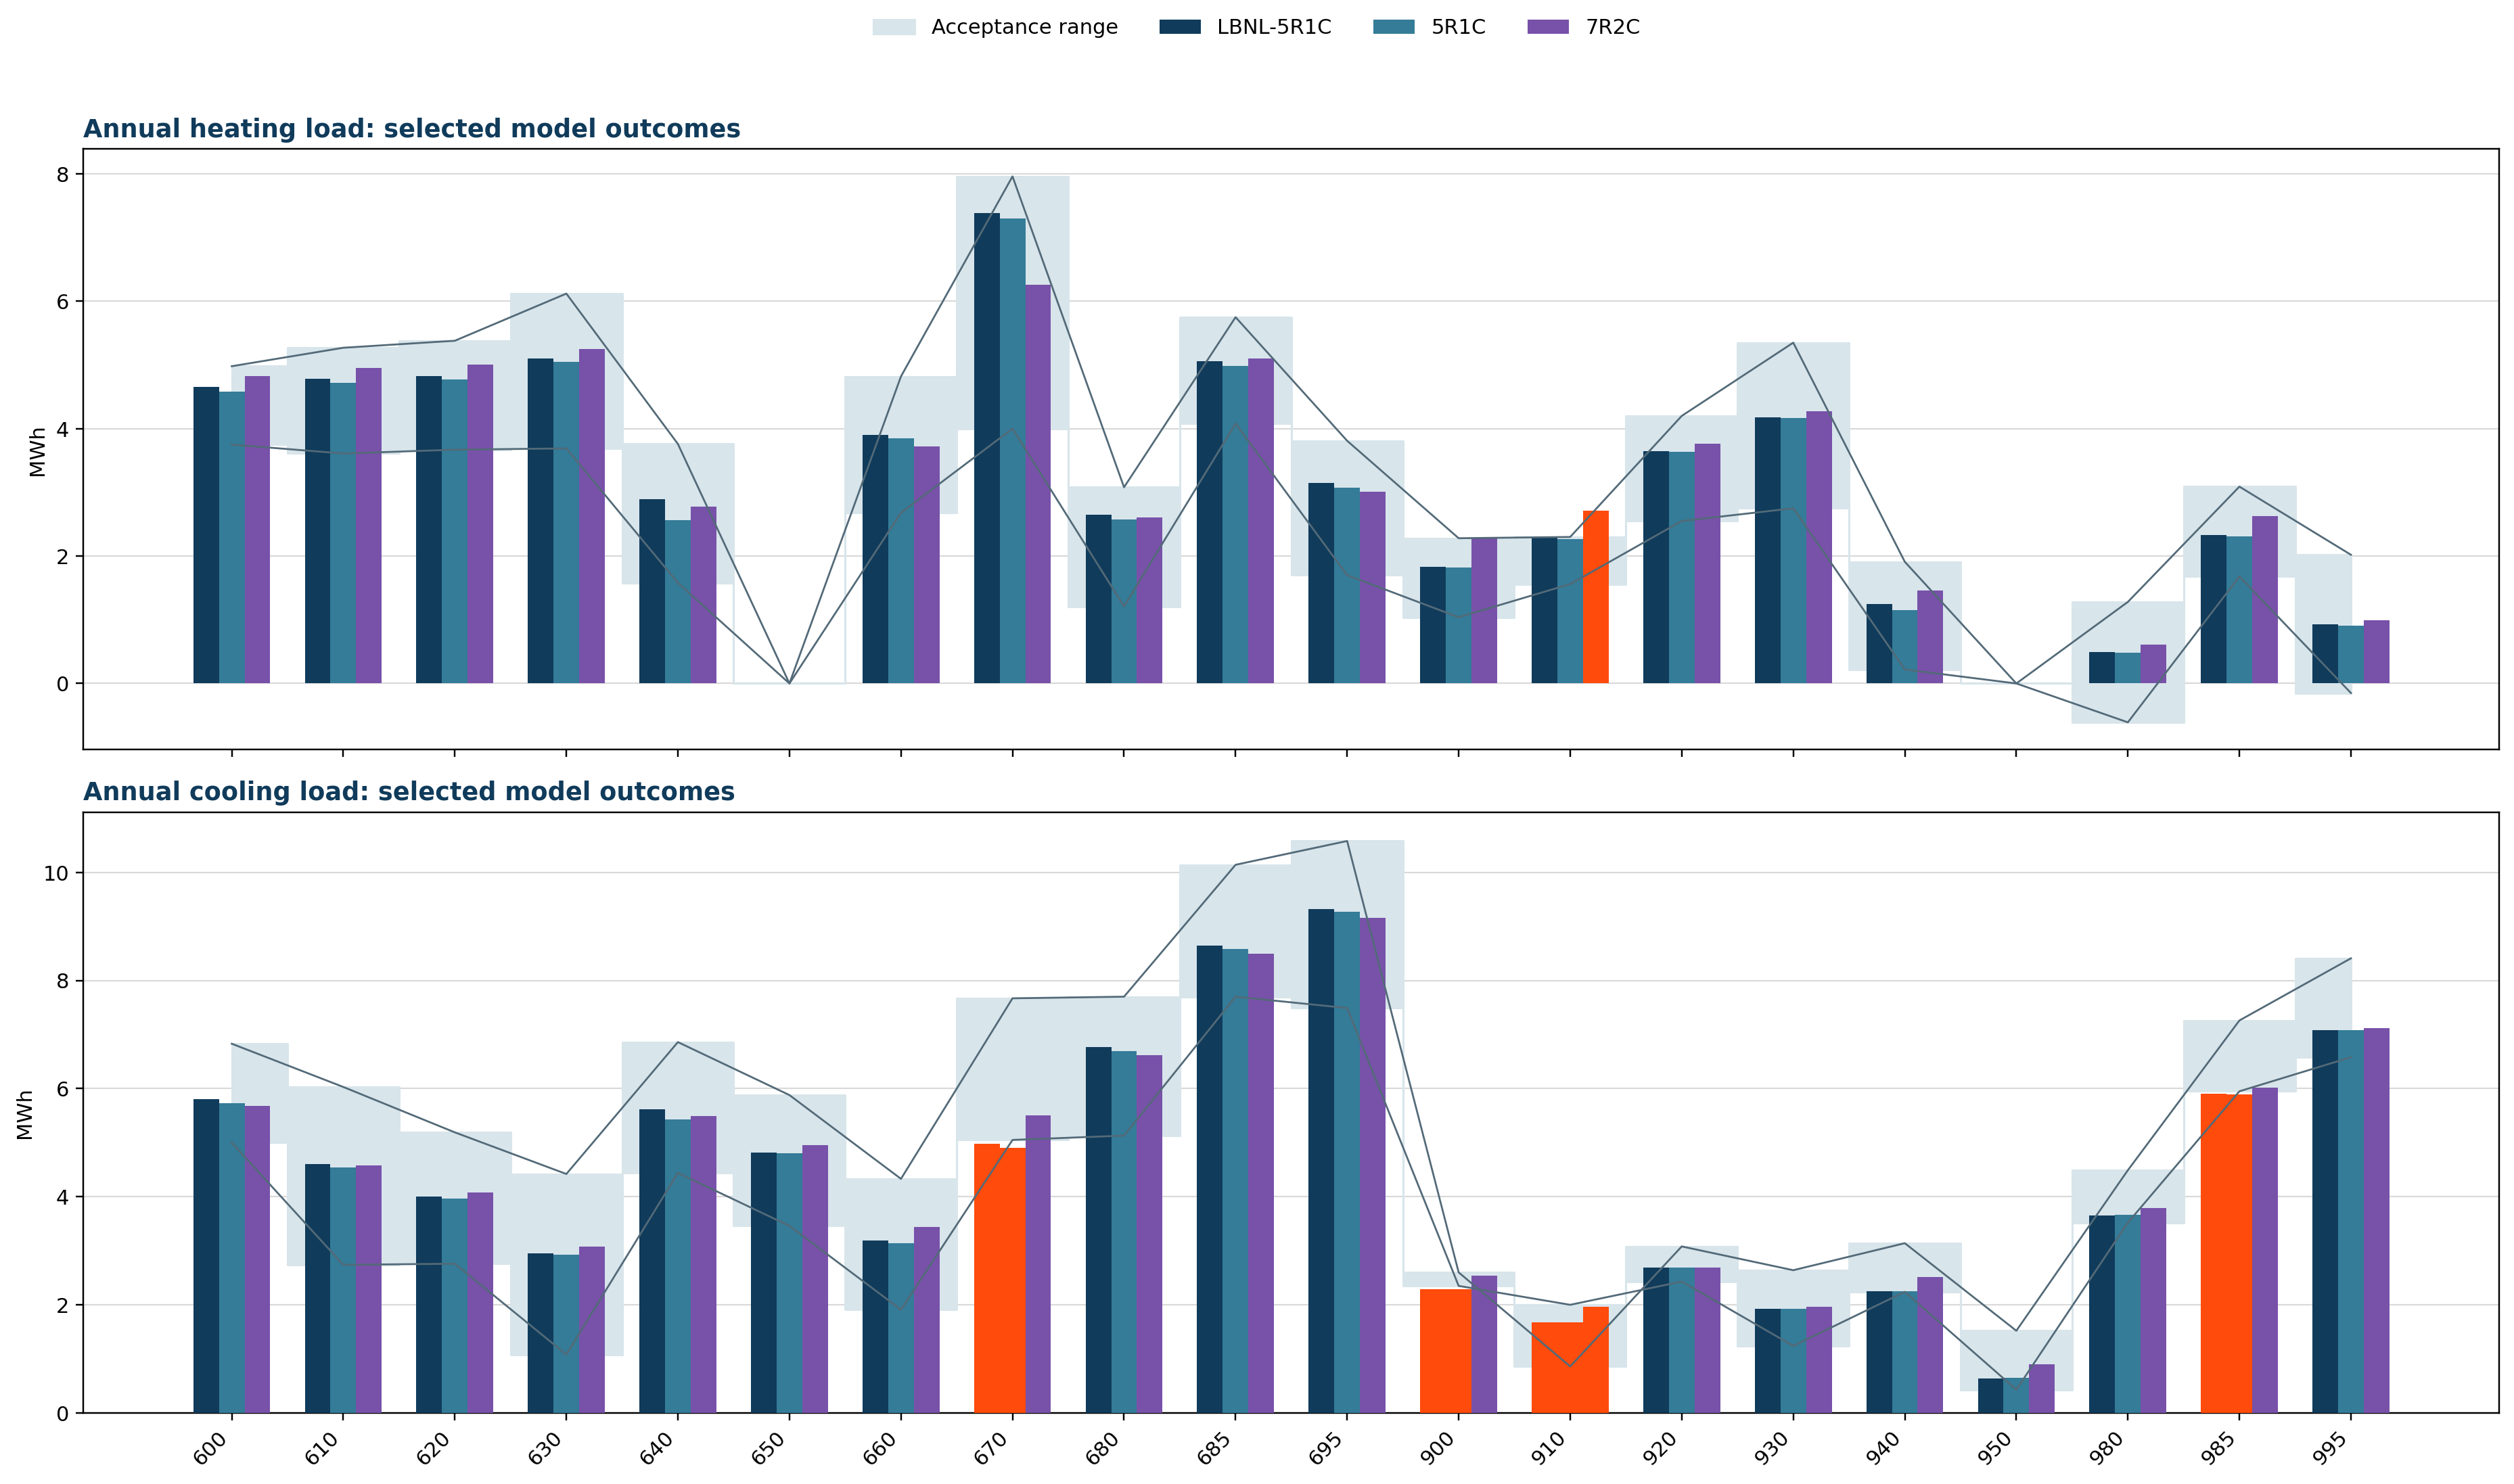

In [3]:
from IPython.display import Image, display

display(Image(filename=output_dir / 'BESTEST_LBNL_EUI_5R1C_7R2C.png'))
display(Image(filename=output_dir / 'BESTEST_LBNL_EUI_5R1C_7R2C_columns.png'))
